In [17]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch

iris = load_iris()
X = iris.data
y = iris.target

scaler = StandardScaler()

x_train, x_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train_t = torch.FloatTensor(x_train)
y_train_t = torch.LongTensor(y_train)

train_dataset = TensorDataset(x_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=24)

class RegressionIris(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = nn.ReLU()(self.fc1(x))
        x = nn.ReLU()(self.fc2(x))
        output = self.fc3(x)
        return output

In [18]:
from torch.optim import SGD, Adagrad, RMSprop, Adam

model = RegressionIris(4, 16, 3)
criterion = nn.CrossEntropyLoss()

In [21]:
from tqdm import tqdm
import copy

epochs = 200; loss_list = []

optimizers = [
    ('SGD', SGD),
    ('Momentum', lambda params: SGD(params, momentum=0.9)),
    ('Adagrad', Adagrad),
    ('RMSprop', RMSprop),
    ('Adam', Adam)
]

for name, optim_fn in optimizers:
    
    model_copy = copy.deepcopy(model)  # 🔥 핵심 (모델 초기화)
    optimizer = optim_fn(model_copy.parameters())
    
    sub_loss_list = []
    
    for epoch in tqdm(range(epochs), desc=name):
        total_loss = 0.0
        
        for x, y in train_loader:
            optimizer.zero_grad()
            
            predict = model_copy(x)
            loss = criterion(predict, y)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        sub_loss_list.append(total_loss / len(train_loader))
    
    loss_list.append((name, sub_loss_list))

Adam: 100%|██████████| 200/200 [00:01<00:00, 150.21it/s]


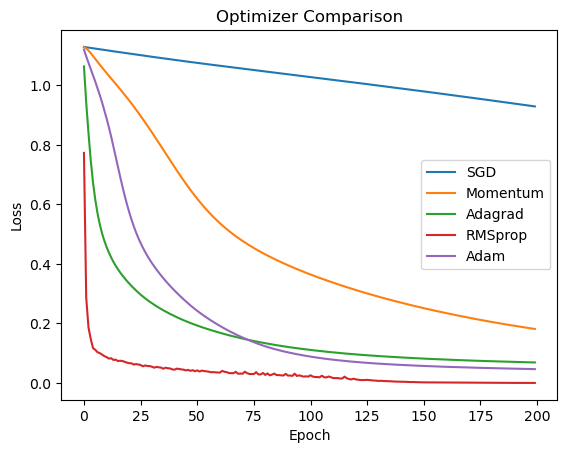

In [22]:
import matplotlib.pyplot as plt

for name, losses in loss_list:
    plt.plot(losses, label=name)

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparison")
plt.show()